# M3

In [ ]:
import os, re, json, math
import numpy as np
import pandas as pd
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    precision_recall_curve, brier_score_loss, confusion_matrix
)

import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 140)
pd.set_option("display.max_rows", 200)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


MIMIC_DIR = Path("/kaggle/input/mimic4")

CANDIDATES = {
    "d_labitems": [MIMIC_DIR / "d_labitems.csv", MIMIC_DIR / "hosp" / "d_labitems.csv"],
    "labevents":  [MIMIC_DIR / "labevents.csv",  MIMIC_DIR / "hosp" / "labevents.csv"],
    "admissions": [MIMIC_DIR / "admissions.csv", MIMIC_DIR / "hosp" / "admissions.csv"],
    "diagnoses":  [MIMIC_DIR / "diagnoses_icd.csv", MIMIC_DIR / "hosp" / "diagnoses_icd.csv"],
}

def pick_path(cands):
    for p in cands:
        if p.exists():
            return p
    return None

DLABITEMS_PATH = pick_path(CANDIDATES["d_labitems"])
LABEVENTS_PATH = pick_path(CANDIDATES["labevents"])
ADMISSIONS_PATH = pick_path(CANDIDATES["admissions"])
DIAGNOSES_PATH = pick_path(CANDIDATES["diagnoses"])

assert DLABITEMS_PATH and LABEVENTS_PATH and ADMISSIONS_PATH and DIAGNOSES_PATH, "Nu pot rezolva toate path-urile MIMIC."

print("Resolved:")
print(" -", DLABITEMS_PATH)
print(" -", LABEVENTS_PATH)
print(" -", ADMISSIONS_PATH)
print(" -", DIAGNOSES_PATH)


OUT_ROOT = Path("/kaggle/working/m3_outputs")
OUT_ROOT.mkdir(parents=True, exist_ok=True)

ITEMSETS_DIR = OUT_ROOT / "m3_itemid_sets"
STRICT_DATA_DIR = OUT_ROOT / "m3_data_strict"
PARTS_DIR = STRICT_DATA_DIR / "parts"
TENSORS_DIR_V2 = OUT_ROOT / "m3_tensors_v2"
RESULTS_DIR = OUT_ROOT / "m3_results"

for p in [ITEMSETS_DIR, STRICT_DATA_DIR, PARTS_DIR, TENSORS_DIR_V2, RESULTS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("OUT_ROOT:", OUT_ROOT)


device: cuda
GPU: Tesla P100-PCIE-16GB
Resolved:
 - /kaggle/input/mimic4/d_labitems.csv
 - /kaggle/input/mimic4/labevents.csv
 - /kaggle/input/mimic4/admissions.csv
 - /kaggle/input/mimic4/diagnoses_icd.csv
OUT_ROOT: /kaggle/working/m3_outputs


In [ ]:

CHUNKSIZE = 1_000_000
MAX_ROWS = None

HORIZON_HOURS = 48
BUCKET_HOURS = 4
T_STEPS = int(math.ceil(HORIZON_HOURS / BUCKET_HOURS))

BLOOD_LIKE = {"Blood", "Serum", "Plasma", "Whole Blood"}
FILTER_TO_BLOOD_LIKE = True

FILTER_TO_MOST_COMMON_UNIT = True
Z_CLIP = 10.0


REBUILD_PARTS_IF_EXIST = True
REBUILD_TENSORS_IF_EXIST = True

BATCH_SIZE = 256 if device.type == "cuda" else 64
NUM_WORKERS = 2
EPOCHS_BASE = 6               # ablations
EPOCHS_BEST = 10              # best model

print("T_STEPS:", T_STEPS, "| BUCKET_HOURS:", BUCKET_HOURS, "| HORIZON_HOURS:", HORIZON_HOURS)


T_STEPS: 12 | BUCKET_HOURS: 4 | HORIZON_HOURS: 48


## Step 1 - Itemids (load if exists, else regenerate)

In [24]:
def find_itemids_by_label_regex(dlab_df: pd.DataFrame, pattern: str, flags=re.IGNORECASE):
    rx = re.compile(pattern, flags)
    tmp = dlab_df.copy()
    tmp["label_str"] = tmp["label"].astype(str)
    m = tmp["label_str"].apply(lambda x: bool(rx.search(x)))
    cols = [c for c in ["itemid", "label", "fluid", "category", "loinc_code"] if c in tmp.columns]
    return tmp.loc[m, cols].drop_duplicates("itemid").sort_values("label")

def ensure_itemsets():
    strict_path = ITEMSETS_DIR / "strict_m3_itemids.csv"
    testo_path  = ITEMSETS_DIR / "testosterone_itemids.csv"
    cardio_json = ITEMSETS_DIR / "cardio_concepts_itemids.json"
    labels_path = ITEMSETS_DIR / "strict_m3_itemids_with_labels.csv"

    if strict_path.exists() and testo_path.exists() and cardio_json.exists() and labels_path.exists():
        print("OK: using existing itemsets from:", ITEMSETS_DIR)
        strict = pd.read_csv(strict_path)["itemid"].astype(int).tolist()
        testo  = pd.read_csv(testo_path)["itemid"].astype(int).tolist()
        labels = pd.read_csv(labels_path)
        with open(cardio_json, "r") as f:
            cardio = json.load(f)
        return strict, testo, labels, cardio

    print("Itemsets not found -> regenerating...")
    dlab = pd.read_csv(DLABITEMS_PATH, low_memory=False)

    testosterone_df = find_itemids_by_label_regex(
        dlab,
        r"\btestosterone\b|\bfree\s+testosterone\b|\btotal\s+testosterone\b"
    )
    testosterone_itemids = sorted(testosterone_df["itemid"].dropna().astype(int).unique().tolist())

    CARDIO_CONCEPTS = {
        "troponin": r"\btroponin\b|\btnI\b|\btnT\b|\bcTn\b",
        "bnp_ntprobnp": r"\bBNP\b|\bNT\s*-?\s*pro\s*BNP\b|\bpro\s*BNP\b|\bnatriuretic\b",
        "creatinine": r"\bcreatinine\b",
        "bun_urea": r"\bBUN\b|\burea\b|\burea\s+nitrogen\b",
        "sodium": r"\bsodium\b|\bna\+?\b",
        "potassium": r"\bpotassium\b|\bk\+?\b",
        "hemoglobin": r"\bhemoglobin\b|\bhgb\b",
        "hematocrit": r"\bhematocrit\b|\bhct\b",
        "wbc": r"\bWBC\b|\bwhite\s+blood\s+cell\b|\bleukocyte\b",
        "platelets": r"\bplatelet\b|\bplt\b",
        "crp": r"\bCRP\b|\bC\s*-?\s*reactive\b",
        "albumin": r"\balbumin\b",
        "glucose": r"\bglucose\b|\bdextrose\b",
    }

    concept_to_itemids = {}
    for concept, pattern in CARDIO_CONCEPTS.items():
        df = find_itemids_by_label_regex(dlab, pattern)
        concept_to_itemids[concept] = df["itemid"].dropna().astype(int).unique().tolist()

    cardio_itemids_all = sorted(set().union(*[set(v) for v in concept_to_itemids.values()]))
    strict_m3_itemids = sorted(set(testosterone_itemids).union(cardio_itemids_all))

    pd.DataFrame({"itemid": testosterone_itemids}).to_csv(testo_path, index=False)
    pd.DataFrame({"itemid": cardio_itemids_all}).to_csv(ITEMSETS_DIR / "cardio_itemids_all.csv", index=False)
    pd.DataFrame({"itemid": strict_m3_itemids}).to_csv(strict_path, index=False)
    with open(cardio_json, "w") as f:
        json.dump({k: sorted(set(map(int, v))) for k, v in concept_to_itemids.items()}, f, indent=2)

    cols = [c for c in ["itemid", "label", "fluid", "category", "loinc_code"] if c in dlab.columns]
    strict_labels = dlab[cols]
    strict_labels = strict_labels[strict_labels["itemid"].isin(strict_m3_itemids)].drop_duplicates("itemid")
    strict_labels = strict_labels.sort_values(["label", "itemid"])
    strict_labels.to_csv(labels_path, index=False)

    return strict_m3_itemids, testosterone_itemids, strict_labels, concept_to_itemids

strict_m3_itemids, testosterone_itemids, strict_labels, cardio_concepts = ensure_itemsets()
print("Strict:", len(strict_m3_itemids), "| Testo:", len(testosterone_itemids))


OK: using existing itemsets from: /kaggle/working/m3_outputs/m3_itemid_sets
Strict: 201 | Testo: 4


## Step 2A - Cohort + HF label + patient split

In [25]:
admissions = pd.read_csv(ADMISSIONS_PATH, usecols=["subject_id", "hadm_id", "admittime"])
admissions["admittime"] = pd.to_datetime(admissions["admittime"], errors="coerce")
admissions = admissions.dropna(subset=["subject_id", "hadm_id", "admittime"]).copy()
admissions["subject_id"] = admissions["subject_id"].astype(int)
admissions["hadm_id"] = admissions["hadm_id"].astype(int)

diag = pd.read_csv(DIAGNOSES_PATH, usecols=["subject_id", "hadm_id", "icd_code", "icd_version"])
diag["hadm_id"] = diag["hadm_id"].astype(int)
diag["icd_code"] = diag["icd_code"].astype(str).str.strip()

is_hf_10 = (diag["icd_version"] == 10) & diag["icd_code"].str.startswith("I50")
is_hf_9  = (diag["icd_version"] == 9)  & diag["icd_code"].str.startswith("428")
hf_hadm = set(diag.loc[is_hf_10 | is_hf_9, "hadm_id"].unique().tolist())

admissions["label_hf"] = admissions["hadm_id"].isin(hf_hadm).astype(int)

rng = np.random.default_rng(SEED)
subjects = admissions["subject_id"].drop_duplicates().to_numpy()
rng.shuffle(subjects)

n = len(subjects)
n_train = int(0.70 * n)
n_val   = int(0.15 * n)

train_subjects = set(subjects[:n_train])
val_subjects   = set(subjects[n_train:n_train+n_val])
test_subjects  = set(subjects[n_train+n_val:])

def assign_split(sid: int) -> str:
    if sid in train_subjects: return "train"
    if sid in val_subjects: return "val"
    return "test"

admissions["split"] = admissions["subject_id"].map(assign_split)

print("Cohort:", admissions.shape)
print("Split counts:", admissions["split"].value_counts().to_dict())
print("HF rate overall:", float(admissions["label_hf"].mean()))
display(admissions.groupby("split")["label_hf"].mean().to_frame("hf_rate"))

cohort_path = STRICT_DATA_DIR / "cohort_admissions.csv"
admissions.to_csv(cohort_path, index=False)
print("Saved:", cohort_path)


Cohort: (546028, 5)
Split counts: {'train': 381403, 'test': 82806, 'val': 81819}
HF rate overall: 0.1476316232867179


,hf_rate
split,
test,0.151752
train,0.147243
val,0.145272


Saved: /kaggle/working/m3_outputs/m3_data_strict/cohort_admissions.csv


## Final itemids (blood-like + testosterone)

In [26]:
strict_labels["itemid"] = strict_labels["itemid"].astype(int)

if FILTER_TO_BLOOD_LIKE:
    is_blood_like = strict_labels["fluid"].isin(BLOOD_LIKE) | strict_labels["fluid"].isna()
else:
    is_blood_like = pd.Series([True] * len(strict_labels), index=strict_labels.index)

final_itemids = sorted(set(strict_labels.loc[is_blood_like, "itemid"].tolist()).union(set(testosterone_itemids)))
itemid_to_col = {it: i for i, it in enumerate(final_itemids)}

print("final_itemids:", len(final_itemids))
print("testosterone columns:", sum(1 for it in final_itemids if it in set(testosterone_itemids)))

pd.DataFrame({"itemid": final_itemids}).to_csv(STRICT_DATA_DIR / "final_itemids.csv", index=False)


final_itemids: 89
testosterone columns: 4


## Helpers + testosterone unit conversion

In [27]:
def iter_labevents_chunks(path: Path, chunksize: int, usecols, max_rows=None):
    loaded = 0
    for chunk in pd.read_csv(path, chunksize=chunksize, usecols=usecols, low_memory=False):
        yield chunk
        loaded += len(chunk)
        if max_rows is not None and loaded >= max_rows:
            break

NMOL_L_TO_NG_DL = 28.84

def normalize_testosterone(valuenum: pd.Series, uom: pd.Series):
    u = uom.astype(str).str.strip().str.lower()
    x = pd.to_numeric(valuenum, errors="coerce")

    is_ngdl = u.str.contains("ng/dl", na=False)
    is_nmol = u.str.contains("nmol/l", na=False)

    x2 = x.copy()
    u2 = uom.copy()

    x2.loc[is_nmol] = x.loc[is_nmol] * NMOL_L_TO_NG_DL
    u2.loc[is_nmol] = "ng/dL"
    u2.loc[is_ngdl] = "ng/dL"
    return x2, u2


## PASS 1: top unit per itemid (train-only)

In [28]:
from collections import defaultdict

unit_counts_path = STRICT_DATA_DIR / "train_itemid_unit_counts.csv"
top_unit_path = STRICT_DATA_DIR / "train_itemid_top_unit.csv"

if FILTER_TO_MOST_COMMON_UNIT and (not top_unit_path.exists() or REBUILD_PARTS_IF_EXIST):
    print("Computing unit counts on TRAIN...")
    usecols = ["hadm_id", "itemid", "charttime", "valuenum", "valueuom"]

    admit_map = admissions.set_index("hadm_id")["admittime"]
    train_hadm = set(admissions.loc[admissions["split"]=="train", "hadm_id"].astype(int))

    counts = defaultdict(lambda: defaultdict(int))

    for chunk in iter_labevents_chunks(LABEVENTS_PATH, CHUNKSIZE, usecols, MAX_ROWS):
        chunk = chunk[chunk["itemid"].isin(final_itemids)]
        chunk = chunk[chunk["hadm_id"].isin(train_hadm)]
        if chunk.empty:
            continue

        chunk = chunk.dropna(subset=["charttime"])
        chunk["charttime"] = pd.to_datetime(chunk["charttime"], errors="coerce")
        chunk = chunk.dropna(subset=["charttime"])
        if chunk.empty:
            continue

        chunk["admittime"] = chunk["hadm_id"].map(admit_map)
        chunk = chunk.dropna(subset=["admittime"])
        if chunk.empty:
            continue

        delta_h = (chunk["charttime"] - chunk["admittime"]).dt.total_seconds() / 3600.0
        chunk = chunk[(delta_h >= 0) & (delta_h <= HORIZON_HOURS)]
        if chunk.empty:
            continue

        is_testo_rows = chunk["itemid"].isin(set(testosterone_itemids))
        if is_testo_rows.any():
            _, u_norm = normalize_testosterone(chunk.loc[is_testo_rows, "valuenum"], chunk.loc[is_testo_rows, "valueuom"])
            chunk.loc[is_testo_rows, "valueuom"] = u_norm

        uu = chunk["valueuom"].fillna("NA").astype(str).str.strip()
        for it, u in zip(chunk["itemid"].astype(int).to_numpy(), uu.to_numpy()):
            counts[int(it)][u] += 1

    rows = []
    for it, ud in counts.items():
        for u, c in ud.items():
            rows.append({"itemid": it, "unit": u, "count": c})

    df = pd.DataFrame(rows).sort_values(["itemid","count"], ascending=[True, False])
    df.to_csv(unit_counts_path, index=False)

    top = df.sort_values(["itemid","count"], ascending=[True, False]).groupby("itemid").head(1)
    top.to_csv(top_unit_path, index=False)

    print("Saved:", unit_counts_path)
    print("Saved:", top_unit_path)
else:
    print("SKIP unit count scan.")


Computing unit counts on TRAIN...
Saved: /kaggle/working/m3_outputs/m3_data_strict/train_itemid_unit_counts.csv
Saved: /kaggle/working/m3_outputs/m3_data_strict/train_itemid_top_unit.csv


## PASS 2: train stats (Welford) + PASS 3: extract parts (z-score)

In [ ]:
stats_path = STRICT_DATA_DIR / "train_itemid_stats.csv"
parts_exist = any(PARTS_DIR.glob("part_*.parquet")) or any(PARTS_DIR.glob("part_*.csv"))

usecols_events = ["subject_id", "hadm_id", "itemid", "charttime", "valuenum", "valueuom"]

admit_map = admissions.set_index("hadm_id")["admittime"]
split_map = admissions.set_index("hadm_id")["split"]
label_map = admissions.set_index("hadm_id")["label_hf"]
train_hadm = set(admissions.loc[admissions["split"]=="train", "hadm_id"].astype(int))

top_unit = {}
if FILTER_TO_MOST_COMMON_UNIT and top_unit_path.exists():
    tu = pd.read_csv(top_unit_path)
    top_unit = dict(zip(tu["itemid"].astype(int), tu["unit"].astype(str)))
    print("Loaded top_unit for", len(top_unit), "itemids")

def keep_top_unit(df: pd.DataFrame) -> pd.DataFrame:
    if not FILTER_TO_MOST_COMMON_UNIT or not top_unit:
        return df
    u = df["valueuom"].fillna("NA").astype(str).str.strip()
    top = df["itemid"].astype(int).map(top_unit).fillna("NA")
    return df[u == top]


if (not stats_path.exists()) or REBUILD_PARTS_IF_EXIST:
    from collections import defaultdict
    print("Computing train stats (Welford)...")
    count = defaultdict(int)
    mean  = defaultdict(float)
    M2    = defaultdict(float)

    def welford_update(it, x):
        c = count[it] + 1
        count[it] = c
        delta = x - mean[it]
        mean[it] += delta / c
        delta2 = x - mean[it]
        M2[it] += delta * delta2

    for chunk in iter_labevents_chunks(LABEVENTS_PATH, CHUNKSIZE, usecols_events, MAX_ROWS):
        chunk = chunk[chunk["itemid"].isin(final_itemids)]
        chunk = chunk[chunk["hadm_id"].isin(train_hadm)]
        if chunk.empty:
            continue

        chunk = chunk.dropna(subset=["valuenum", "charttime"])
        if chunk.empty:
            continue

        chunk["charttime"] = pd.to_datetime(chunk["charttime"], errors="coerce")
        chunk = chunk.dropna(subset=["charttime"])
        if chunk.empty:
            continue

        chunk["admittime"] = chunk["hadm_id"].map(admit_map)
        chunk = chunk.dropna(subset=["admittime"])
        if chunk.empty:
            continue

        delta_h = (chunk["charttime"] - chunk["admittime"]).dt.total_seconds() / 3600.0
        chunk = chunk[(delta_h >= 0) & (delta_h < HORIZON_HOURS)]
        if chunk.empty:
            continue

        is_testo_rows = chunk["itemid"].isin(set(testosterone_itemids))
        if is_testo_rows.any():
            x_norm, u_norm = normalize_testosterone(
                chunk.loc[is_testo_rows, "valuenum"],
                chunk.loc[is_testo_rows, "valueuom"]
            )
            chunk.loc[is_testo_rows, "valuenum"] = x_norm
            chunk.loc[is_testo_rows, "valueuom"] = u_norm

        chunk["valuenum"] = pd.to_numeric(chunk["valuenum"], errors="coerce")
        chunk = chunk.dropna(subset=["valuenum"])
        if chunk.empty:
            continue

        chunk = keep_top_unit(chunk)
        if chunk.empty:
            continue

        it_arr = chunk["itemid"].astype(int).to_numpy()
        x_arr  = chunk["valuenum"].astype(float).to_numpy()
        for it, x in zip(it_arr, x_arr):
            welford_update(int(it), float(x))

    stats = []
    for it in final_itemids:
        c = count.get(it, 0)
        if c < 2:
            continue
        var = M2[it] / (c - 1)
        std = float(np.sqrt(var)) if var > 0 else 1.0
        stats.append({"itemid": int(it), "count": int(c), "mean": float(mean[it]), "std": float(std)})

    stats_df = pd.DataFrame(stats).sort_values("count", ascending=False)
    stats_df.to_csv(stats_path, index=False)
    print("Saved:", stats_path)
else:
    print("Stats exist:", stats_path)


if parts_exist and (not REBUILD_PARTS_IF_EXIST):
    print("SKIP extraction: parts already exist in", PARTS_DIR)
else:
    print("Extracting parts (filtered + zscored) ...")
    stats_df = pd.read_csv(stats_path)
    mu = dict(zip(stats_df["itemid"].astype(int), stats_df["mean"].astype(float)))
    sd = dict(zip(stats_df["itemid"].astype(int), stats_df["std"].astype(float)))

    def zscore(it, x):
        it = int(it)
        if it not in mu:
            return np.nan
        s = sd[it]
        if s == 0:
            return 0.0
        z = (x - mu[it]) / s
        if Z_CLIP is not None:
            z = float(np.clip(z, -Z_CLIP, Z_CLIP))
        return z


    try:
        import pyarrow  # noqa
        CAN_PARQUET = True
    except Exception:
        CAN_PARQUET = False

    for p in PARTS_DIR.glob("part_*"):
        p.unlink()

    parts_cfg = {
        "horizon_hours": float(HORIZON_HOURS),
        "bucket_hours": float(BUCKET_HOURS),
        "T_STEPS": int(T_STEPS),
        "filter_to_blood_like": bool(FILTER_TO_BLOOD_LIKE),
        "filter_to_most_common_unit": bool(FILTER_TO_MOST_COMMON_UNIT),
        "z_clip": float(Z_CLIP) if Z_CLIP is not None else None,
        "chunksize": int(CHUNKSIZE),
        "max_rows": None if MAX_ROWS is None else int(MAX_ROWS),
    }
    with open(PARTS_DIR / "parts_config.json", "w") as f:
        json.dump(parts_cfg, f, indent=2)

    part_idx = 0
    kept_total = 0

    EPS = 1e-9

    for chunk in iter_labevents_chunks(LABEVENTS_PATH, CHUNKSIZE, usecols_events, MAX_ROWS):
        chunk = chunk[chunk["itemid"].isin(final_itemids)]
        if chunk.empty:
            continue

        chunk = chunk[chunk["hadm_id"].isin(admissions["hadm_id"])]
        if chunk.empty:
            continue

        chunk = chunk.dropna(subset=["valuenum", "charttime"])
        if chunk.empty:
            continue

        chunk["charttime"] = pd.to_datetime(chunk["charttime"], errors="coerce")
        chunk = chunk.dropna(subset=["charttime"])
        if chunk.empty:
            continue

        chunk["admittime"] = chunk["hadm_id"].map(admit_map)
        chunk["split"] = chunk["hadm_id"].map(split_map)
        chunk["label_hf"] = chunk["hadm_id"].map(label_map)
        chunk = chunk.dropna(subset=["admittime", "split", "label_hf"])
        if chunk.empty:
            continue

        chunk["delta_hours"] = (chunk["charttime"] - chunk["admittime"]).dt.total_seconds() / 3600.0

        chunk = chunk[(chunk["delta_hours"] >= 0) & (chunk["delta_hours"] < HORIZON_HOURS)]
        if chunk.empty:
            continue

        # bucket: floor((delta - eps)/bucket_hours)
        chunk["bucket"] = np.floor((chunk["delta_hours"].to_numpy() - EPS) / BUCKET_HOURS).astype(int)
        chunk = chunk[(chunk["bucket"] >= 0) & (chunk["bucket"] < T_STEPS)]
        if chunk.empty:
            continue

        is_testo_rows = chunk["itemid"].isin(set(testosterone_itemids))
        if is_testo_rows.any():
            x_norm, u_norm = normalize_testosterone(
                chunk.loc[is_testo_rows, "valuenum"],
                chunk.loc[is_testo_rows, "valueuom"]
            )
            chunk.loc[is_testo_rows, "valuenum"] = x_norm
            chunk.loc[is_testo_rows, "valueuom"] = u_norm

        chunk["valuenum"] = pd.to_numeric(chunk["valuenum"], errors="coerce")
        chunk = chunk.dropna(subset=["valuenum"])
        if chunk.empty:
            continue

        chunk = keep_top_unit(chunk)
        if chunk.empty:
            continue

        chunk["valuenum_z"] = [zscore(it, x) for it, x in zip(chunk["itemid"].to_numpy(), chunk["valuenum"].to_numpy())]
        chunk = chunk.dropna(subset=["valuenum_z"])
        if chunk.empty:
            continue

        chunk["is_testosterone"] = chunk["itemid"].isin(set(testosterone_itemids)).astype(int)

        # charttime_ns (int64)
        chunk["charttime_ns"] = chunk["charttime"].astype("int64")

        out = chunk[[
            "subject_id", "hadm_id", "split", "label_hf",
            "itemid", "bucket", "charttime_ns",
            "valuenum_z", "is_testosterone"
        ]].copy()

        part_file = PARTS_DIR / (f"part_{part_idx:05d}.parquet" if CAN_PARQUET else f"part_{part_idx:05d}.csv")
        if CAN_PARQUET:
            out.to_parquet(part_file, index=False)
        else:
            out.to_csv(part_file, index=False)

        kept_total += len(out)
        part_idx += 1

        if part_idx % 10 == 0:
            print(f"[extract] parts={part_idx} kept_total={kept_total:,}")

    print("DONE extraction. parts:", part_idx, "rows:", kept_total)


Loaded top_unit for 44 itemids
Computing train stats (Welford)...
Saved: /kaggle/working/m3_outputs/m3_data_strict/train_itemid_stats.csv
Extracting parts (filtered + zscored) ...
[extract] parts=10 kept_total=781,781
[extract] parts=20 kept_total=1,568,316
[extract] parts=30 kept_total=2,347,909
[extract] parts=40 kept_total=3,117,690
[extract] parts=50 kept_total=3,897,644
[extract] parts=60 kept_total=4,676,870
[extract] parts=70 kept_total=5,464,183
[extract] parts=80 kept_total=6,240,852
[extract] parts=90 kept_total=7,015,925
[extract] parts=100 kept_total=7,797,037
[extract] parts=110 kept_total=8,576,809
[extract] parts=120 kept_total=9,353,481
[extract] parts=130 kept_total=10,154,098
[extract] parts=140 kept_total=10,923,298
[extract] parts=150 kept_total=11,694,277
DONE extraction. parts: 159 rows: 12341786


## QC quick (sample parts)

In [30]:
def load_part(path: Path):
    if path.suffix == ".parquet":
        return pd.read_parquet(path)
    return pd.read_csv(path)

parts = sorted(PARTS_DIR.glob("part_*.parquet")) if any(PARTS_DIR.glob("*.parquet")) else sorted(PARTS_DIR.glob("part_*.csv"))
assert len(parts) > 0, "Nu exista parts."

sample_n = min(10, len(parts))
df_small = pd.concat([load_part(p) for p in parts[:sample_n]], ignore_index=True)

print("Sample rows:", len(df_small))
print("HF rate (rows sample):", float(df_small["label_hf"].mean()))
print("Testosterone measured rate (sample hadm):", float(df_small.groupby("hadm_id")["is_testosterone"].max().mean()))

display(df_small.groupby("split")["label_hf"].mean().to_frame("hf_rate_rows"))
display(df_small.groupby(["split","hadm_id"])["is_testosterone"].max().groupby("split").mean().to_frame("testo_measured_rate_hadm"))


Sample rows: 781781
HF rate (rows sample): 0.23001326458432733
Testosterone measured rate (sample hadm): 0.0006413400233900479


,hf_rate_rows
split,
test,0.224578
train,0.231811
val,0.227411


,testo_measured_rate_hadm
split,
test,0.000241
train,0.000656
val,0.000985


## Step 2B - Build tensors v2 (FIXED: X_time)

In [ ]:
def load_part(path: Path):
    if path.suffix == ".parquet":
        return pd.read_parquet(path)
    return pd.read_csv(path)

parts = sorted(PARTS_DIR.glob("part_*.parquet")) if any(PARTS_DIR.glob("*.parquet")) else sorted(PARTS_DIR.glob("part_*.csv"))
assert len(parts) > 0, "Nu exista parts."

def build_tensors_v2_for_split(split_name: str, out_dir: Path):
    hadm_df = admissions.loc[admissions["split"] == split_name, ["hadm_id","label_hf"]].copy()
    hadm_ids = hadm_df["hadm_id"].astype(int).to_numpy()
    y = hadm_df["label_hf"].astype(np.uint8).to_numpy()
    N = len(hadm_ids)

    hadm_to_row = {int(h): i for i, h in enumerate(hadm_ids)}

    X_val = np.zeros((N, T_STEPS, len(final_itemids)), dtype=np.float32)
    X_msk = np.zeros((N, T_STEPS, len(final_itemids)), dtype=np.uint8)
    X_tim = np.full((N, T_STEPS, len(final_itemids)), -1, dtype=np.int64)

    for p in parts:
        df = load_part(p)
        df = df[df["split"] == split_name]
        if df.empty:
            continue

        df = df[df["hadm_id"].isin(hadm_to_row)]
        if df.empty:
            continue

        df = df[(df["bucket"] >= 0) & (df["bucket"] < T_STEPS)]
        if df.empty:
            continue

        if "charttime_ns" not in df.columns:
            raise KeyError(
                f"Part file {p.name} nu are 'charttime_ns'. "
                f"Coloane: {list(df.columns)}. Regenereaza parts (REBUILD_PARTS_IF_EXIST=True)."
            )

        df = df.sort_values("charttime_ns")
        df = df.drop_duplicates(subset=["hadm_id","bucket","itemid"], keep="last")

        h_idx = df["hadm_id"].map(hadm_to_row).to_numpy(dtype=np.int64)
        t_idx = df["bucket"].to_numpy(dtype=np.int64)
        f_idx = df["itemid"].map(itemid_to_col).to_numpy(dtype=np.int64)
        ts = df["charttime_ns"].to_numpy(dtype=np.int64)
        v  = df["valuenum_z"].to_numpy(dtype=np.float32)

        cur_ts = X_tim[h_idx, t_idx, f_idx]
        upd = ts > cur_ts
        if np.any(upd):
            hh = h_idx[upd]; tt = t_idx[upd]; ff = f_idx[upd]
            X_tim[hh, tt, ff] = ts[upd]
            X_val[hh, tt, ff] = v[upd]
            X_msk[hh, tt, ff] = 1

    out_path = out_dir / f"{split_name}_bucket_T{T_STEPS}_F{len(final_itemids)}_v2.npz"
    np.savez_compressed(
        out_path,
        X_val=X_val,
        X_msk=X_msk,
        X_time=X_tim,
        y=y,
        final_itemids=np.array(final_itemids, dtype=np.int32),
        bucket_hours=np.array([BUCKET_HOURS], dtype=np.float32),
        horizon_hours=np.array([HORIZON_HOURS], dtype=np.float32),
    )
    print("Saved:", out_path, "| shapes:", X_val.shape, X_msk.shape, X_tim.shape, y.shape)
    return out_path

tensor_files_exist = list(TENSORS_DIR_V2.glob("*_v2.npz"))
if tensor_files_exist and (not REBUILD_TENSORS_IF_EXIST):
    print("SKIP tensor rebuild:", [p.name for p in tensor_files_exist])
else:
    for split_name in ["train", "val", "test"]:
        build_tensors_v2_for_split(split_name, TENSORS_DIR_V2)


Saved: /kaggle/working/m3_outputs/m3_tensors_v2/train_bucket_T12_F89_v2.npz | shapes: (381403, 12, 89) (381403, 12, 89) (381403, 12, 89) (381403,)
Saved: /kaggle/working/m3_outputs/m3_tensors_v2/val_bucket_T12_F89_v2.npz | shapes: (81819, 12, 89) (81819, 12, 89) (81819, 12, 89) (81819,)
Saved: /kaggle/working/m3_outputs/m3_tensors_v2/test_bucket_T12_F89_v2.npz | shapes: (82806, 12, 89) (82806, 12, 89) (82806, 12, 89) (82806,)


## Baselines (LR + HistGB) on static aggregation

In [32]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.pipeline import Pipeline

def load_npz_v2(path: Path):
    d = np.load(path, allow_pickle=True)
    return (d["X_val"].astype(np.float32),
            d["X_msk"].astype(np.float32),
            d["y"].astype(np.int32),
            d["final_itemids"].astype(np.int32).tolist(),
            float(d["bucket_hours"][0]),
            float(d["horizon_hours"][0]))

train_npz = next(TENSORS_DIR_V2.glob("train_*_v2.npz"))
val_npz   = next(TENSORS_DIR_V2.glob("val_*_v2.npz"))
test_npz  = next(TENSORS_DIR_V2.glob("test_*_v2.npz"))

Xv_tr, Xm_tr, y_tr, fids, bh, hh = load_npz_v2(train_npz)
Xv_va, Xm_va, y_va, _, _, _ = load_npz_v2(val_npz)
Xv_te, Xm_te, y_te, _, _, _ = load_npz_v2(test_npz)

T, F = Xv_tr.shape[1], Xv_tr.shape[2]
print("Loaded v2 tensors. T=", T, "F=", F, "bucket_hours=", bh)

testo_set = set(testosterone_itemids)
testo_cols = [i for i, it in enumerate(fids) if int(it) in testo_set]
non_testo_cols = [i for i in range(F) if i not in set(testo_cols)]
print("Testosterone columns:", len(testo_cols))

def static_features(Xv, Xm):
    cnt = Xm.sum(axis=1)
    s = (Xv * Xm).sum(axis=1)
    mean = s / np.maximum(cnt, 1.0)

    t = np.arange(Xm.shape[1], dtype=np.float32).reshape(1, -1, 1)
    last_t = (Xm * t).max(axis=1).astype(np.int64)
    last_val = np.take_along_axis(Xv, last_t[:, None, :], axis=1).squeeze(1)
    last_msk = Xm.max(axis=1)

    if len(testo_cols) > 0:
        testo_meas = Xm[:, :, testo_cols].max(axis=(1,2)).reshape(-1,1)
    else:
        testo_meas = np.zeros((Xm.shape[0], 1), dtype=np.float32)

    return np.concatenate([mean, cnt, last_val, last_msk, testo_meas], axis=1).astype(np.float32)

def eval_probs(y_true, p, name=""):
    auroc = roc_auc_score(y_true, p) if len(np.unique(y_true)) > 1 else float("nan")
    auprc = average_precision_score(y_true, p) if len(np.unique(y_true)) > 1 else float("nan")
    prec, rec, thr = precision_recall_curve(y_true, p)
    f1s = (2*prec*rec) / (prec+rec+1e-12)
    i = int(np.nanargmax(f1s))
    best_thr = float(thr[i]) if i < len(thr) else 0.5
    best_f1 = float(np.nanmax(f1s))
    print(f"{name} AUROC={auroc:.4f} AUPRC={auprc:.4f} bestF1={best_f1:.4f} thr={best_thr:.3f}")
    return {"auroc": float(auroc), "auprc": float(auprc), "best_f1": best_f1, "best_thr": best_thr}

X_tr = static_features(Xv_tr, Xm_tr)
X_va = static_features(Xv_va, Xm_va)
X_te = static_features(Xv_te, Xm_te)

lr = Pipeline([
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("clf", LogisticRegression(max_iter=200, n_jobs=-1, class_weight="balanced", solver="saga"))
])
lr.fit(X_tr, y_tr)
lr_val = eval_probs(y_va, lr.predict_proba(X_va)[:,1], "LR val")
lr_test = eval_probs(y_te, lr.predict_proba(X_te)[:,1], "LR test")

gb = HistGradientBoostingClassifier(max_depth=6, learning_rate=0.05, max_iter=300)
gb.fit(X_tr, y_tr)
gb_val = eval_probs(y_va, gb.predict_proba(X_va)[:,1], "GB val")
gb_test = eval_probs(y_te, gb.predict_proba(X_te)[:,1], "GB test")


Loaded v2 tensors. T= 12 F= 89 bucket_hours= 4.0
Testosterone columns: 4
LR val AUROC=0.8444 AUPRC=0.5448 bestF1=0.5506 thr=0.635
LR test AUROC=0.8426 AUPRC=0.5563 bestF1=0.5528 thr=0.608
GB val AUROC=0.8639 AUPRC=0.6236 bestF1=0.5795 thr=0.268
GB test AUROC=0.8638 AUPRC=0.6295 bestF1=0.5801 thr=0.294


## Deep model (LSTM/GRU) + variants + ablations

In [33]:
class EHRSeqDataset(Dataset):
    def __init__(self, Xv, Xm, y):
        self.Xv = Xv
        self.Xm = Xm
        self.y = y.astype(np.float32)

    def __len__(self):
        return self.y.shape[0]

    def __getitem__(self, idx):
        return self.Xv[idx], self.Xm[idx], self.y[idx]

def make_collate(variant: str, bucket_hours: float):
    def batch_delta_t(mask_btf):
        B, T, F = mask_btf.shape
        dt = np.zeros_like(mask_btf, dtype=np.float32)
        for t in range(1, T):
            dt[:, t, :] = (1.0 - mask_btf[:, t, :]) * (dt[:, t-1, :] + bucket_hours)
        return dt

    def collate(batch):
        v = np.stack([b[0] for b in batch], axis=0).astype(np.float32)
        m = np.stack([b[1] for b in batch], axis=0).astype(np.float32)
        y = torch.tensor([b[2] for b in batch], dtype=torch.float32)

        if variant in ("full", "full_dt"):
            v_use, m_use = v, m

        elif variant in ("no_testo", "no_testo_dt"):
            v_use = v[:, :, non_testo_cols]
            m_use = m[:, :, non_testo_cols]

        elif variant in ("testo_flag_only", "testo_flag_only_dt"):
            v_nt = v[:, :, non_testo_cols]
            m_nt = m[:, :, non_testo_cols]
            flag = m[:, :, testo_cols].max(axis=2, keepdims=True) if len(testo_cols) > 0 else np.zeros((m.shape[0], m.shape[1], 1), dtype=np.float32)
            v_use = np.concatenate([v_nt, np.zeros_like(flag)], axis=2)
            m_use = np.concatenate([m_nt, flag], axis=2)

        else:
            raise ValueError("Unknown variant: " + variant)

        if variant.endswith("_dt"):
            dt = batch_delta_t(m_use)
            x = np.concatenate([v_use, m_use, dt], axis=2)
        else:
            x = np.concatenate([v_use, m_use], axis=2)

        return torch.from_numpy(x), y

    return collate

class RNNClassifier(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int = 128, rnn_type: str = "lstm", dropout: float = 0.2):
        super().__init__()
        rnn_type = rnn_type.lower()
        if rnn_type == "gru":
            self.rnn = nn.GRU(input_size=input_dim, hidden_size=hidden_dim, batch_first=True)
        else:
            self.rnn = nn.LSTM(input_size=input_dim, hidden_size=hidden_dim, batch_first=True)

        self.dropout = nn.Dropout(dropout)
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )
        self.rnn_type = rnn_type

    def forward(self, x):
        out = self.rnn(x)
        if self.rnn_type == "gru":
            _, hn = out
            h_last = hn[-1]
        else:
            _, (hn, _) = out
            h_last = hn[-1]
        h_last = self.dropout(h_last)
        return self.head(h_last).squeeze(-1)

def eval_model(model, loader):
    model.eval()
    ys, ps = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            if device.type == "cuda":
                with torch.amp.autocast("cuda"):
                    logits = model(xb)
            else:
                logits = model(xb)

            prob = torch.sigmoid(logits)
            ys.append(yb.detach().cpu().numpy())
            ps.append(prob.detach().cpu().numpy())

    y = np.concatenate(ys).astype(np.float32)
    p = np.concatenate(ps).astype(np.float32)

    auroc = roc_auc_score(y, p) if len(np.unique(y)) > 1 else float("nan")
    auprc = average_precision_score(y, p) if len(np.unique(y)) > 1 else float("nan")

    prec, rec, thr = precision_recall_curve(y, p)
    f1s = (2*prec*rec) / (prec+rec+1e-12)
    i = int(np.nanargmax(f1s))
    best_thr = float(thr[i]) if i < len(thr) else 0.5
    best_f1 = float(np.nanmax(f1s))

    return {"auroc": float(auroc), "auprc": float(auprc), "best_thr": best_thr, "best_f1": best_f1, "y": y, "p": p}

def train_rnn(variant: str, rnn_type: str = "lstm", epochs: int = 6, lr: float = 3e-4, hidden_dim: int = 128, dropout: float = 0.2):
    train_ds = EHRSeqDataset(Xv_tr, Xm_tr, y_tr)
    val_ds   = EHRSeqDataset(Xv_va, Xm_va, y_va)

    collate = make_collate(variant, bucket_hours=bh)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS,
                              pin_memory=(device.type=="cuda"), collate_fn=collate)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
                            pin_memory=(device.type=="cuda"), collate_fn=collate)

    input_dim = next(iter(train_loader))[0].shape[-1]
    model = RNNClassifier(input_dim=input_dim, hidden_dim=hidden_dim, rnn_type=rnn_type, dropout=dropout).to(device)

    pos = float(y_tr.sum()); neg = float(len(y_tr) - y_tr.sum())
    pos_weight = torch.tensor([neg / max(pos, 1.0)], device=device, dtype=torch.float32)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scaler = torch.amp.GradScaler("cuda") if device.type == "cuda" else None

    best = None
    best_state = None

    for ep in range(1, epochs+1):
        model.train()
        tot, n = 0.0, 0

        for xb, yb in train_loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            if device.type == "cuda":
                with torch.amp.autocast("cuda"):
                    logits = model(xb)
                    loss = criterion(logits, yb)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                logits = model(xb)
                loss = criterion(logits, yb)
                loss.backward()
                optimizer.step()

            tot += float(loss.item()) * xb.size(0)
            n += xb.size(0)

        tr_loss = tot / max(n, 1)
        val_metrics = eval_model(model, val_loader)
        print(f"[{variant}/{rnn_type}] ep={ep:02d} loss={tr_loss:.4f} val AUROC={val_metrics['auroc']:.4f} val AUPRC={val_metrics['auprc']:.4f} val F1={val_metrics['best_f1']:.4f} thr={val_metrics['best_thr']:.3f}")

        if best is None or val_metrics["auprc"] > best["auprc"]:
            best = {k: val_metrics[k] for k in ["auroc","auprc","best_thr","best_f1"]}
            best_state = {k: v.detach().cpu() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    return model, best


## Run ablations + pick best + calibration + occlusion + save


TRAIN: full | lstm
[full/lstm] ep=01 loss=0.8450 val AUROC=0.8553 val AUPRC=0.5937 val F1=0.5603 thr=0.721
[full/lstm] ep=02 loss=0.8096 val AUROC=0.8574 val AUPRC=0.6049 val F1=0.5666 thr=0.652
[full/lstm] ep=03 loss=0.8000 val AUROC=0.8595 val AUPRC=0.6131 val F1=0.5704 thr=0.660
[full/lstm] ep=04 loss=0.7940 val AUROC=0.8624 val AUPRC=0.6173 val F1=0.5732 thr=0.687
[full/lstm] ep=05 loss=0.7895 val AUROC=0.8630 val AUPRC=0.6206 val F1=0.5764 thr=0.697
[full/lstm] ep=06 loss=0.7849 val AUROC=0.8628 val AUPRC=0.6213 val F1=0.5789 thr=0.722

TRAIN: no_testo | lstm
[no_testo/lstm] ep=01 loss=0.8456 val AUROC=0.8559 val AUPRC=0.5923 val F1=0.5607 thr=0.703
[no_testo/lstm] ep=02 loss=0.8085 val AUROC=0.8576 val AUPRC=0.6042 val F1=0.5655 thr=0.640
[no_testo/lstm] ep=03 loss=0.8006 val AUROC=0.8596 val AUPRC=0.6126 val F1=0.5689 thr=0.731
[no_testo/lstm] ep=04 loss=0.7938 val AUROC=0.8616 val AUPRC=0.6180 val F1=0.5735 thr=0.658
[no_testo/lstm] ep=05 loss=0.7897 val AUROC=0.8635 val AUPRC

,model,variant,val_auroc,val_auprc,val_best_f1,val_best_thr,test_auroc,test_auprc,test_f1_at_valthr
2,lstm,testo_flag_only,0.864106,0.622576,0.577014,0.680664,0.862359,0.626745,0.577970
1,lstm,no_testo,0.864263,0.622246,0.576999,0.671387,0.862933,0.625924,0.575991
0,lstm,full,0.862806,0.621303,0.578939,0.721680,0.861223,0.624702,0.576567
3,lstm,full_dt,0.852313,0.580404,0.556511,0.708984,0.850359,0.583691,0.553122


Saved: /kaggle/working/m3_outputs/m3_results/deep_ablation_results.csv
Best deep: lstm testo_flag_only
[testo_flag_only/lstm] ep=01 loss=0.8461 val AUROC=0.8553 val AUPRC=0.5941 val F1=0.5605 thr=0.691
[testo_flag_only/lstm] ep=02 loss=0.8073 val AUROC=0.8583 val AUPRC=0.6080 val F1=0.5677 thr=0.728
[testo_flag_only/lstm] ep=03 loss=0.7984 val AUROC=0.8616 val AUPRC=0.6148 val F1=0.5723 thr=0.707
[testo_flag_only/lstm] ep=04 loss=0.7921 val AUROC=0.8626 val AUPRC=0.6192 val F1=0.5764 thr=0.711
[testo_flag_only/lstm] ep=05 loss=0.7877 val AUROC=0.8635 val AUPRC=0.6211 val F1=0.5770 thr=0.693
[testo_flag_only/lstm] ep=06 loss=0.7851 val AUROC=0.8640 val AUPRC=0.6241 val F1=0.5776 thr=0.721
[testo_flag_only/lstm] ep=07 loss=0.7822 val AUROC=0.8653 val AUPRC=0.6273 val F1=0.5802 thr=0.746
[testo_flag_only/lstm] ep=08 loss=0.7807 val AUROC=0.8655 val AUPRC=0.6275 val F1=0.5822 thr=0.690
[testo_flag_only/lstm] ep=09 loss=0.7774 val AUROC=0.8656 val AUPRC=0.6279 val F1=0.5805 thr=0.644
[testo

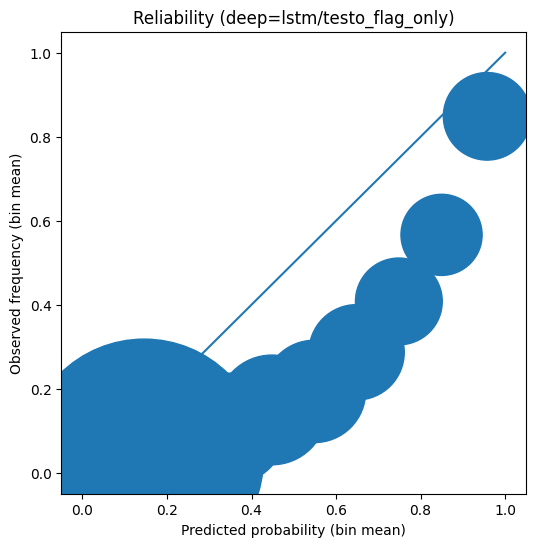

,group,n_cols,base_auprc,occl_auprc,delta_auprc,base_auroc,occl_auroc,delta_auroc
14,hematocrit,5,0.634653,0.543884,0.090769,0.864358,0.826641,0.037717
13,hemoglobin,23,0.634653,0.544456,0.090197,0.864358,0.819675,0.044683
4,bun_urea,2,0.634653,0.579582,0.055072,0.864358,0.840791,0.023567
8,chloride,4,0.634653,0.599174,0.035479,0.864358,0.853492,0.010866
10,magnesium,1,0.634653,0.599399,0.035254,0.864358,0.852269,0.012089
3,creatinine,3,0.634653,0.611626,0.023028,0.864358,0.860253,0.004105
7,potassium,5,0.634653,0.615831,0.018823,0.864358,0.849628,0.014731
6,sodium,5,0.634653,0.617904,0.016749,0.864358,0.858562,0.005796
1,troponin,3,0.634653,0.619951,0.014702,0.864358,0.858739,0.005619
9,bicarbonate_co2,4,0.634653,0.622914,0.011739,0.864358,0.861096,0.003262


Saved: /kaggle/working/m3_outputs/m3_results/occlusion_group_importance.csv
Saved ckpt: /kaggle/working/m3_outputs/best_m3_deep_lstm_testo_flag_only.pt
Saved config: /kaggle/working/m3_outputs/m3_run_config.json


In [ ]:
variants = ["full", "no_testo", "testo_flag_only", "full_dt"]
rnn_types = ["lstm"]

results = []
test_ds = EHRSeqDataset(Xv_te, Xm_te, y_te)

for rnn_type in rnn_types:
    for variant in variants:
        print("\n==============================")
        print("TRAIN:", variant, "|", rnn_type)
        print("==============================")

        model, _ = train_rnn(variant=variant, rnn_type=rnn_type, epochs=EPOCHS_BASE)

        collate = make_collate(variant, bucket_hours=bh)
        val_loader = DataLoader(EHRSeqDataset(Xv_va, Xm_va, y_va), batch_size=BATCH_SIZE, shuffle=False,
                                num_workers=NUM_WORKERS, pin_memory=(device.type=="cuda"), collate_fn=collate)
        test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                                 num_workers=NUM_WORKERS, pin_memory=(device.type=="cuda"), collate_fn=collate)

        val_m = eval_model(model, val_loader)
        te_m  = eval_model(model, test_loader)

        thr = val_m["best_thr"]
        yhat = (te_m["p"] >= thr).astype(int)
        f1_at_thr = float(f1_score(te_m["y"], yhat))

        results.append({
            "model": rnn_type,
            "variant": variant,
            "val_auroc": val_m["auroc"],
            "val_auprc": val_m["auprc"],
            "val_best_f1": val_m["best_f1"],
            "val_best_thr": val_m["best_thr"],
            "test_auroc": te_m["auroc"],
            "test_auprc": te_m["auprc"],
            "test_f1_at_valthr": f1_at_thr,
        })

res_df = pd.DataFrame(results).sort_values(["model","val_auprc"], ascending=[True, False])
display(res_df)

res_path = RESULTS_DIR / "deep_ablation_results.csv"
res_df.to_csv(res_path, index=False)
print("Saved:", res_path)

best_row = res_df.iloc[0]
best_variant = best_row["variant"]
best_rnn = best_row["model"]
print("Best deep:", best_rnn, best_variant)

best_model, _ = train_rnn(variant=best_variant, rnn_type=best_rnn, epochs=EPOCHS_BEST)

collate = make_collate(best_variant, bucket_hours=bh)
val_loader = DataLoader(EHRSeqDataset(Xv_va, Xm_va, y_va), batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=(device.type=="cuda"), collate_fn=collate)
test_loader = DataLoader(EHRSeqDataset(Xv_te, Xm_te, y_te), batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=(device.type=="cuda"), collate_fn=collate)

val_m = eval_model(best_model, val_loader)
te_m  = eval_model(best_model, test_loader)

print("Deep VAL:", {k: val_m[k] for k in ["auroc","auprc","best_f1","best_thr"]})
print("Deep TEST:", {k: te_m[k] for k in ["auroc","auprc","best_f1","best_thr"]})

print("\nBaselines (test):")
print(" - LR :", lr_test)
print(" - GB :", gb_test)

thr = val_m["best_thr"]
yhat = (te_m["p"] >= thr).astype(int)

cm = confusion_matrix(te_m["y"].astype(int), yhat)
print("\nConfusion matrix @thr(val):")
print(cm)

brier = float(brier_score_loss(te_m["y"], te_m["p"]))
print("Test Brier:", brier)

bins = 10
edges = np.linspace(0.0, 1.0, bins+1)
bin_ids = np.clip(np.digitize(te_m["p"], edges) - 1, 0, bins-1)

conf = np.array([te_m["p"][bin_ids==i].mean() if np.any(bin_ids==i) else np.nan for i in range(bins)])
acc  = np.array([te_m["y"][bin_ids==i].mean() if np.any(bin_ids==i) else np.nan for i in range(bins)])
cnt  = np.array([np.sum(bin_ids==i) for i in range(bins)])

plt.figure(figsize=(6,6))
plt.plot([0,1],[0,1])
plt.scatter(conf, acc, s=np.maximum(cnt, 1))
plt.xlabel("Predicted probability (bin mean)")
plt.ylabel("Observed frequency (bin mean)")
plt.title(f"Reliability (deep={best_rnn}/{best_variant})")
plt.show()

group_to_cols = {"testosterone": testo_cols}
cardio_json = ITEMSETS_DIR / "cardio_concepts_itemids.json"
if cardio_json.exists():
    with open(cardio_json, "r") as f:
        cardio_map = json.load(f)
    for g, itemids in cardio_map.items():
        cols = [i for i, it in enumerate(fids) if int(it) in set(map(int, itemids))]
        if cols:
            group_to_cols[g] = cols

def occlusion_group(cols_to_zero):
    Xv_occ = Xv_te.copy()
    Xm_occ = Xm_te.copy()
    if len(cols_to_zero) > 0:
        Xv_occ[:, :, cols_to_zero] = 0.0
        Xm_occ[:, :, cols_to_zero] = 0.0

    occ_loader = DataLoader(EHRSeqDataset(Xv_occ, Xm_occ, y_te), batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=(device.type=="cuda"), collate_fn=collate)
    occ_m = eval_model(best_model, occ_loader)
    return float(occ_m["auprc"]), float(occ_m["auroc"])

base_auprc = float(te_m["auprc"])
base_auroc = float(te_m["auroc"])

rows = []
for g, cols in group_to_cols.items():
    auprc_g, auroc_g = occlusion_group(cols)
    rows.append({
        "group": g,
        "n_cols": len(cols),
        "base_auprc": base_auprc,
        "occl_auprc": auprc_g,
        "delta_auprc": base_auprc - auprc_g,
        "base_auroc": base_auroc,
        "occl_auroc": auroc_g,
        "delta_auroc": base_auroc - auroc_g,
    })

imp_df = pd.DataFrame(rows).sort_values("delta_auprc", ascending=False)
display(imp_df)

imp_path = RESULTS_DIR / "occlusion_group_importance.csv"
imp_df.to_csv(imp_path, index=False)
print("Saved:", imp_path)

ckpt_path = OUT_ROOT / f"best_m3_deep_{best_rnn}_{best_variant}.pt"
torch.save({
    "model_type": best_rnn,
    "variant": best_variant,
    "state_dict": best_model.state_dict(),
    "T": int(T),
    "F": int(F),
    "bucket_hours": float(bh),
    "horizon_hours": float(hh),
    "final_itemids": fids,
    "testosterone_itemids": testosterone_itemids,
}, ckpt_path)

cfg_path = OUT_ROOT / "m3_run_config.json"
with open(cfg_path, "w") as f:
    json.dump({
        "seed": SEED,
        "chunksize": CHUNKSIZE,
        "max_rows": MAX_ROWS,
        "horizon_hours": HORIZON_HOURS,
        "bucket_hours": BUCKET_HOURS,
        "T_steps": T_STEPS,
        "filter_to_blood_like": FILTER_TO_BLOOD_LIKE,
        "filter_to_most_common_unit": FILTER_TO_MOST_COMMON_UNIT,
        "z_clip": Z_CLIP,
        "best_model_type": best_rnn,
        "best_variant": best_variant,
        "tensor_files_v2": {
            "train": str(train_npz),
            "val": str(val_npz),
            "test": str(test_npz),
        },
    }, f, indent=2)

print("Saved ckpt:", ckpt_path)
print("Saved config:", cfg_path)


In [ ]:
import json, glob, os, re, math
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve, roc_curve,
    brier_score_loss, confusion_matrix, f1_score
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

OUT_ROOT = Path("/kaggle/working/m3_outputs")
RESULTS_DIR = OUT_ROOT / "m3_results"
TENSORS_DIR_V2 = OUT_ROOT / "m3_tensors_v2"
ITEMSETS_DIR = OUT_ROOT / "m3_itemid_sets"
STRICT_DATA_DIR = OUT_ROOT / "m3_data_strict"
FIG_DIR = OUT_ROOT / "m3_report_assets" / "figures"
TAB_DIR = OUT_ROOT / "m3_report_assets" / "tables"
PRED_DIR = OUT_ROOT / "m3_report_assets" / "predictions"
for p in [FIG_DIR, TAB_DIR, PRED_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("OUT_ROOT:", OUT_ROOT)

deep_path = Path("/kaggle/working/deep_ablation_results.csv")
occ_path  = Path("/kaggle/working/occlusion_group_importance.csv")
cfg_path  = Path("/kaggle/working/m3_run_config.json")
stats_path = Path("/kaggle/working/train_itemid_stats.csv")

if not deep_path.exists():
    deep_path = RESULTS_DIR / "deep_ablation_results.csv"
if not occ_path.exists():
    occ_path = RESULTS_DIR / "occlusion_group_importance.csv"
if not cfg_path.exists():
    cfg_path = OUT_ROOT / "m3_run_config.json"
if not stats_path.exists():
    stats_path = STRICT_DATA_DIR / "train_itemid_stats.csv"

assert deep_path.exists(), f"Missing {deep_path}"
assert occ_path.exists(), f"Missing {occ_path}"
assert cfg_path.exists(), f"Missing {cfg_path}"
assert stats_path.exists(), f"Missing {stats_path}"

deep_df = pd.read_csv(deep_path)
occ_df  = pd.read_csv(occ_path)
stats_df = pd.read_csv(stats_path)

with open(cfg_path, "r") as f:
    run_cfg = json.load(f)

print("Loaded:")
print(" -", deep_path)
print(" -", occ_path)
print(" -", cfg_path)
print(" -", stats_path)

display(deep_df.sort_values("val_auprc", ascending=False))
display(occ_df.sort_values("delta_auprc", ascending=False).head(15))


parts_cfg_out = STRICT_DATA_DIR / "parts" / "parts_config.json"
parts_cfg_out.parent.mkdir(parents=True, exist_ok=True)
if not parts_cfg_out.exists():
    with open(parts_cfg_out, "w") as f:
        json.dump({
            "note": "Generated post-hoc from m3_run_config.json + current notebook state. Parts were already extracted.",
            "horizon_hours": run_cfg.get("horizon_hours"),
            "bucket_hours": run_cfg.get("bucket_hours"),
            "T_steps": run_cfg.get("T_steps"),
            "filter_to_blood_like": run_cfg.get("filter_to_blood_like"),
            "filter_to_most_common_unit": run_cfg.get("filter_to_most_common_unit"),
            "z_clip": run_cfg.get("z_clip"),
            "chunksize": run_cfg.get("chunksize"),
            "max_rows": run_cfg.get("max_rows"),
        }, f, indent=2)
    print("Wrote:", parts_cfg_out)
else:
    print("parts_config.json already exists:", parts_cfg_out)


OUT_ROOT: /kaggle/working/m3_outputs
Loaded:
 - /kaggle/working/m3_outputs/m3_results/deep_ablation_results.csv
 - /kaggle/working/m3_outputs/m3_results/occlusion_group_importance.csv
 - /kaggle/working/m3_outputs/m3_run_config.json
 - /kaggle/working/m3_outputs/m3_data_strict/train_itemid_stats.csv


,model,variant,val_auroc,val_auprc,val_best_f1,val_best_thr,test_auroc,test_auprc,test_f1_at_valthr
0,lstm,testo_flag_only,0.864106,0.622576,0.577014,0.680664,0.862359,0.626745,0.577970
1,lstm,no_testo,0.864263,0.622246,0.576999,0.671387,0.862933,0.625924,0.575991
2,lstm,full,0.862806,0.621303,0.578939,0.721680,0.861223,0.624702,0.576567
3,lstm,full_dt,0.852313,0.580404,0.556511,0.708984,0.850359,0.583691,0.553122


,group,n_cols,base_auprc,occl_auprc,delta_auprc,base_auroc,occl_auroc,delta_auroc
0,hematocrit,5,0.634653,0.543884,0.090769,0.864358,0.826641,0.037717
1,hemoglobin,23,0.634653,0.544456,0.090197,0.864358,0.819675,0.044683
2,bun_urea,2,0.634653,0.579582,0.055072,0.864358,0.840791,0.023567
3,chloride,4,0.634653,0.599174,0.035479,0.864358,0.853492,0.010866
4,magnesium,1,0.634653,0.599399,0.035254,0.864358,0.852269,0.012089
5,creatinine,3,0.634653,0.611626,0.023028,0.864358,0.860253,0.004105
6,potassium,5,0.634653,0.615831,0.018823,0.864358,0.849628,0.014731
7,sodium,5,0.634653,0.617904,0.016749,0.864358,0.858562,0.005796
8,troponin,3,0.634653,0.619951,0.014702,0.864358,0.858739,0.005619
9,bicarbonate_co2,4,0.634653,0.622914,0.011739,0.864358,0.861096,0.003262


parts_config.json already exists: /kaggle/working/m3_outputs/m3_data_strict/parts/parts_config.json


In [ ]:
def load_npz_v2(path: Path):
    d = np.load(path, allow_pickle=True)
    return (d["X_val"].astype(np.float32),
            d["X_msk"].astype(np.float32),
            d["y"].astype(np.int32),
            d["final_itemids"].astype(np.int32).tolist(),
            float(d["bucket_hours"][0]),
            float(d["horizon_hours"][0]))

# --- find tensors
train_npz = next(TENSORS_DIR_V2.glob("train_*_v2.npz"))
val_npz   = next(TENSORS_DIR_V2.glob("val_*_v2.npz"))
test_npz  = next(TENSORS_DIR_V2.glob("test_*_v2.npz"))

Xv_tr, Xm_tr, y_tr, fids, bh, hh = load_npz_v2(train_npz)
Xv_va, Xm_va, y_va, _, _, _ = load_npz_v2(val_npz)
Xv_te, Xm_te, y_te, _, _, _ = load_npz_v2(test_npz)

T = Xv_tr.shape[1]
F = Xv_tr.shape[2]
print("Tensors loaded:", "T=",T,"F=",F,"bucket_hours=",bh,"horizon_hours=",hh)

# --- find checkpoint saved by training cell
ckpts = sorted(OUT_ROOT.glob("best_m3_deep_*.pt"))
assert len(ckpts) > 0, f"Nu gasesc checkpoint in {OUT_ROOT} (best_m3_deep_*.pt)."
ckpt_path = ckpts[-1]
print("Using checkpoint:", ckpt_path)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

ckpt = torch.load(ckpt_path, map_location="cpu")
best_variant = ckpt["variant"]
best_rnn = ckpt["model_type"]
testosterone_itemids = set(map(int, ckpt.get("testosterone_itemids", [])))

testo_cols = [i for i, it in enumerate(fids) if int(it) in testosterone_itemids]
non_testo_cols = [i for i in range(F) if i not in set(testo_cols)]
print("best_variant:", best_variant, "| best_rnn:", best_rnn)
print("testosterone cols:", len(testo_cols))

# --- Define collate (same logic as in training) but for inference
def make_infer_collate(variant: str, bucket_hours: float):
    def batch_delta_t(mask_btf):
        B, T, F = mask_btf.shape
        dt = np.zeros_like(mask_btf, dtype=np.float32)
        for t in range(1, T):
            dt[:, t, :] = (1.0 - mask_btf[:, t, :]) * (dt[:, t-1, :] + bucket_hours)
        return dt

    def collate(batch):
        v = np.stack([b[0] for b in batch], axis=0).astype(np.float32)
        m = np.stack([b[1] for b in batch], axis=0).astype(np.float32)
        y = torch.tensor([b[2] for b in batch], dtype=torch.float32)

        if variant in ("full", "full_dt"):
            v_use, m_use = v, m

        elif variant in ("no_testo", "no_testo_dt"):
            v_use = v[:, :, non_testo_cols]
            m_use = m[:, :, non_testo_cols]

        elif variant in ("testo_flag_only", "testo_flag_only_dt"):
            v_nt = v[:, :, non_testo_cols]
            m_nt = m[:, :, non_testo_cols]
            flag = m[:, :, testo_cols].max(axis=2, keepdims=True) if len(testo_cols) > 0 else np.zeros((m.shape[0], m.shape[1], 1), dtype=np.float32)
            v_use = np.concatenate([v_nt, np.zeros_like(flag)], axis=2)
            m_use = np.concatenate([m_nt, flag], axis=2)

        else:
            raise ValueError("Unknown variant: " + variant)

        if variant.endswith("_dt"):
            dt = batch_delta_t(m_use)
            x = np.concatenate([v_use, m_use, dt], axis=2)
        else:
            x = np.concatenate([v_use, m_use], axis=2)

        return torch.from_numpy(x), y
    return collate

# --- Model definition
class RNNClassifier(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int = 128, rnn_type: str = "lstm", dropout: float = 0.2):
        super().__init__()
        rnn_type = rnn_type.lower()
        if rnn_type == "gru":
            self.rnn = nn.GRU(input_size=input_dim, hidden_size=hidden_dim, batch_first=True)
        else:
            self.rnn = nn.LSTM(input_size=input_dim, hidden_size=hidden_dim, batch_first=True)

        self.dropout = nn.Dropout(dropout)
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )
        self.rnn_type = rnn_type

    def forward(self, x):
        out = self.rnn(x)
        if self.rnn_type == "gru":
            _, hn = out
            h_last = hn[-1]
        else:
            _, (hn, _) = out
            h_last = hn[-1]
        h_last = self.dropout(h_last)
        return self.head(h_last).squeeze(-1)

class EHRSeqDataset(Dataset):
    def __init__(self, Xv, Xm, y):
        self.Xv = Xv
        self.Xm = Xm
        self.y = y.astype(np.float32)
    def __len__(self): return self.y.shape[0]
    def __getitem__(self, idx): return self.Xv[idx], self.Xm[idx], self.y[idx]

def infer_probs(model, loader):
    model.eval()
    ys, ps = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            if device.type == "cuda":
                with torch.amp.autocast("cuda"):
                    logits = model(xb)
            else:
                logits = model(xb)
            prob = torch.sigmoid(logits)
            ys.append(yb.detach().cpu().numpy())
            ps.append(prob.detach().cpu().numpy())
    y = np.concatenate(ys).astype(np.float32)
    p = np.concatenate(ps).astype(np.float32)
    return y, p

def best_f1_threshold(y, p):
    prec, rec, thr = precision_recall_curve(y, p)
    f1s = (2*prec*rec) / (prec+rec+1e-12)
    i = int(np.nanargmax(f1s))
    return float(thr[i]) if i < len(thr) else 0.5, float(np.nanmax(f1s))

# --- Build loaders (inference only)
BATCH = 512 if device.type=="cuda" else 128
collate = make_infer_collate(best_variant, bucket_hours=bh)

val_loader = DataLoader(EHRSeqDataset(Xv_va, Xm_va, y_va), batch_size=BATCH, shuffle=False, num_workers=2,
                        pin_memory=(device.type=="cuda"), collate_fn=collate)
test_loader = DataLoader(EHRSeqDataset(Xv_te, Xm_te, y_te), batch_size=BATCH, shuffle=False, num_workers=2,
                         pin_memory=(device.type=="cuda"), collate_fn=collate)

# --- Determine input_dim from one batch
xb0, _ = next(iter(val_loader))
input_dim = xb0.shape[-1]
print("input_dim:", input_dim)

# --- Load model weights
model = RNNClassifier(input_dim=input_dim, hidden_dim=128, rnn_type=best_rnn, dropout=0.2).to(device)
model.load_state_dict(ckpt["state_dict"], strict=True)

# --- Predict
y_val, p_val = infer_probs(model, val_loader)
y_test, p_test = infer_probs(model, test_loader)

# --- Metrics
val_auroc = roc_auc_score(y_val, p_val)
val_auprc = average_precision_score(y_val, p_val)
thr, val_best_f1 = best_f1_threshold(y_val, p_val)

test_auroc = roc_auc_score(y_test, p_test)
test_auprc = average_precision_score(y_test, p_test)
yhat = (p_test >= thr).astype(int)
test_f1 = float(f1_score(y_test, yhat))
cm = confusion_matrix(y_test.astype(int), yhat)

print(f"VAL  AUROC={val_auroc:.4f} AUPRC={val_auprc:.4f} bestF1={val_best_f1:.4f} thr={thr:.3f}")
print(f"TEST AUROC={test_auroc:.4f} AUPRC={test_auprc:.4f} F1@thr(val)={test_f1:.4f}")
print("Confusion matrix @thr(val):\n", cm)

np.save(PRED_DIR / "y_val.npy", y_val)
np.save(PRED_DIR / "p_val.npy", p_val)
np.save(PRED_DIR / "y_test.npy", y_test)
np.save(PRED_DIR / "p_test.npy", p_test)

metrics_out = {
    "best_variant": best_variant,
    "best_rnn": best_rnn,
    "val": {"auroc": float(val_auroc), "auprc": float(val_auprc), "best_f1": float(val_best_f1), "best_thr": float(thr)},
    "test": {"auroc": float(test_auroc), "auprc": float(test_auprc), "f1_at_valthr": float(test_f1), "confusion_matrix": cm.tolist()},
}
with open(PRED_DIR / "deep_metrics.json", "w") as f:
    json.dump(metrics_out, f, indent=2)

print("Saved predictions + metrics into:", PRED_DIR)


Tensors loaded: T= 12 F= 89 bucket_hours= 4.0 horizon_hours= 48.0
Using checkpoint: /kaggle/working/m3_outputs/best_m3_deep_lstm_testo_flag_only.pt
device: cuda
best_variant: testo_flag_only | best_rnn: lstm
testosterone cols: 4
input_dim: 172
VAL  AUROC=0.8657 AUPRC=0.6287 bestF1=0.5816 thr=0.656
TEST AUROC=0.8644 AUPRC=0.6347 F1@thr(val)=0.5825
Confusion matrix @thr(val):
 [[64467  5773]
 [ 5029  7537]]
Saved predictions + metrics into: /kaggle/working/m3_outputs/m3_report_assets/predictions


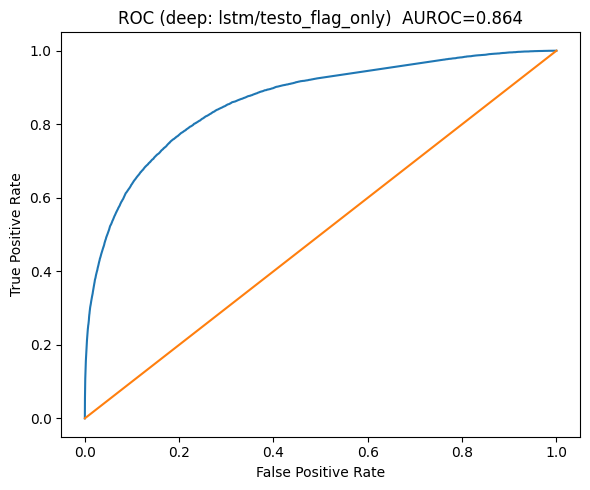

Saved: /kaggle/working/m3_outputs/m3_report_assets/figures/roc_deep.png


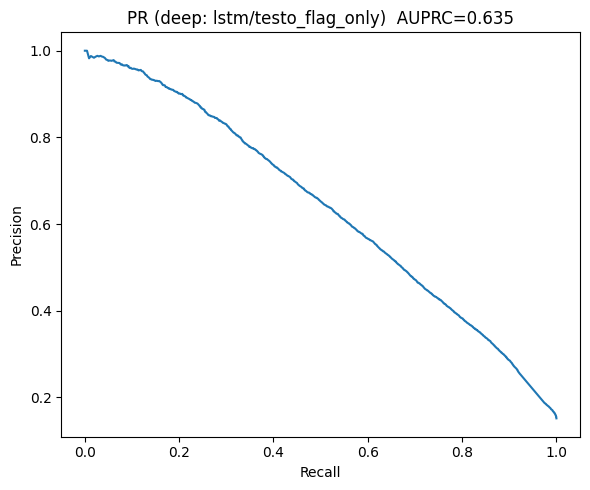

Saved: /kaggle/working/m3_outputs/m3_report_assets/figures/pr_deep.png


In [37]:
# ROC
fpr, tpr, _ = roc_curve(y_test, p_test)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC (deep: {best_rnn}/{best_variant})  AUROC={test_auroc:.3f}")
roc_path = FIG_DIR / "roc_deep.png"
plt.tight_layout()
plt.savefig(roc_path, dpi=200)
plt.show()
print("Saved:", roc_path)

# PR
prec, rec, _ = precision_recall_curve(y_test, p_test)
plt.figure(figsize=(6,5))
plt.plot(rec, prec)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"PR (deep: {best_rnn}/{best_variant})  AUPRC={test_auprc:.3f}")
pr_path = FIG_DIR / "pr_deep.png"
plt.tight_layout()
plt.savefig(pr_path, dpi=200)
plt.show()
print("Saved:", pr_path)


Brier: 0.12920972079118936
ECE: 0.17970197244378583


,bin,count,p_mean,y_mean,abs_gap
0,0,11980,0.053120,0.013272,0.039848
1,1,29512,0.146009,0.034054,0.111955
2,2,7240,0.247699,0.068370,0.179329
3,3,6391,0.350587,0.104835,0.245752
4,4,6240,0.448188,0.149519,0.298669
5,5,5432,0.548928,0.193667,0.355261
6,6,4716,0.648529,0.286684,0.361846
7,7,3906,0.748600,0.407834,0.340766
8,8,3413,0.849549,0.566364,0.283185
9,9,3976,0.957392,0.848592,0.108801


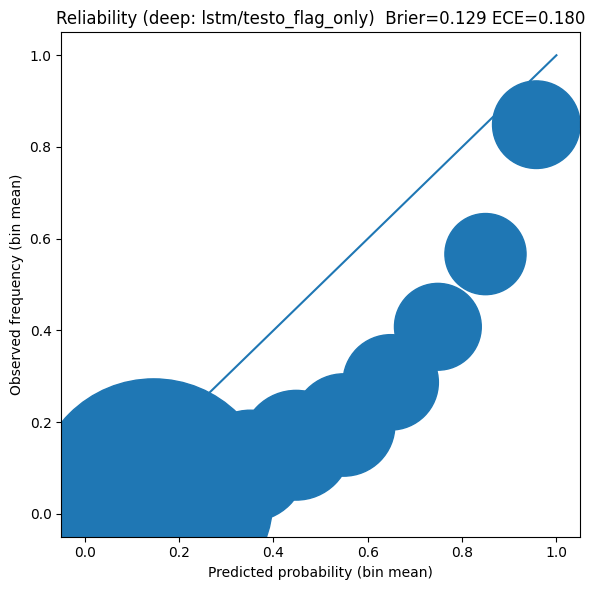

Saved: /kaggle/working/m3_outputs/m3_report_assets/figures/calibration_deep.png
Saved: /kaggle/working/m3_outputs/m3_report_assets/tables/calibration_bins.csv


In [38]:
def expected_calibration_error(y, p, bins=10):
    edges = np.linspace(0.0, 1.0, bins+1)
    bin_ids = np.clip(np.digitize(p, edges) - 1, 0, bins-1)

    ece = 0.0
    rows = []
    n = len(y)
    for i in range(bins):
        m = (bin_ids == i)
        if not np.any(m):
            rows.append({"bin": i, "count": 0, "p_mean": np.nan, "y_mean": np.nan, "abs_gap": np.nan})
            continue
        p_mean = float(p[m].mean())
        y_mean = float(y[m].mean())
        gap = abs(p_mean - y_mean)
        w = float(m.mean())
        ece += w * gap
        rows.append({"bin": i, "count": int(m.sum()), "p_mean": p_mean, "y_mean": y_mean, "abs_gap": gap})
    return float(ece), pd.DataFrame(rows)

brier = float(brier_score_loss(y_test, p_test))
ece, cal_df = expected_calibration_error(y_test, p_test, bins=10)

print("Brier:", brier)
print("ECE:", ece)
display(cal_df)

cal_df.to_csv(TAB_DIR / "calibration_bins.csv", index=False)

# Reliability plot
plt.figure(figsize=(6,6))
plt.plot([0,1],[0,1])
plt.scatter(cal_df["p_mean"], cal_df["y_mean"], s=np.maximum(cal_df["count"].to_numpy(), 1))
plt.xlabel("Predicted probability (bin mean)")
plt.ylabel("Observed frequency (bin mean)")
plt.title(f"Reliability (deep: {best_rnn}/{best_variant})  Brier={brier:.3f} ECE={ece:.3f}")
cal_path = FIG_DIR / "calibration_deep.png"
plt.tight_layout()
plt.savefig(cal_path, dpi=200)
plt.show()
print("Saved:", cal_path)
print("Saved:", TAB_DIR / "calibration_bins.csv")


Saved: /kaggle/working/m3_outputs/m3_report_assets/tables/deep_ablation_results.csv


,model,variant,val_auroc,val_auprc,val_best_f1,val_best_thr,test_auroc,test_auprc,test_f1_at_valthr
0,lstm,testo_flag_only,0.864106,0.622576,0.577014,0.680664,0.862359,0.626745,0.577970
1,lstm,no_testo,0.864263,0.622246,0.576999,0.671387,0.862933,0.625924,0.575991
2,lstm,full,0.862806,0.621303,0.578939,0.721680,0.861223,0.624702,0.576567
3,lstm,full_dt,0.852313,0.580404,0.556511,0.708984,0.850359,0.583691,0.553122


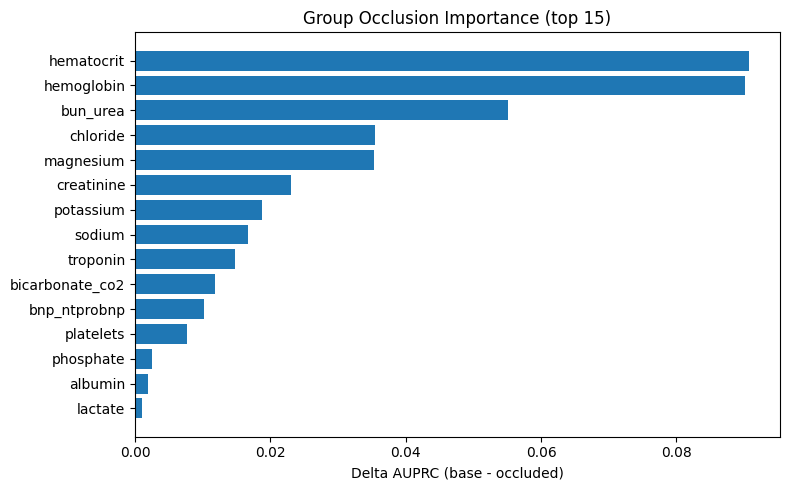

Saved: /kaggle/working/m3_outputs/m3_report_assets/figures/occlusion_top15.png
Saved: /kaggle/working/m3_outputs/m3_report_assets/tables/occlusion_group_importance.csv


In [ ]:
deep_df_sorted = deep_df.sort_values("val_auprc", ascending=False).copy()
deep_df_sorted.to_csv(TAB_DIR / "deep_ablation_results.csv", index=False)
print("Saved:", TAB_DIR / "deep_ablation_results.csv")
display(deep_df_sorted)

occ_sorted = occ_df.sort_values("delta_auprc", ascending=False).copy()
occ_sorted.to_csv(TAB_DIR / "occlusion_group_importance.csv", index=False)

topk = 15
x = occ_sorted.head(topk)["group"].astype(str).to_numpy()
y = occ_sorted.head(topk)["delta_auprc"].to_numpy()

plt.figure(figsize=(8,5))
plt.barh(x[::-1], y[::-1])
plt.xlabel("Delta AUPRC (base - occluded)")
plt.title(f"Group Occlusion Importance (top {topk})")
occ_path = FIG_DIR / "occlusion_top15.png"
plt.tight_layout()
plt.savefig(occ_path, dpi=200)
plt.show()
print("Saved:", occ_path)
print("Saved:", TAB_DIR / "occlusion_group_importance.csv")


In [ ]:
# din stats_df: cate valori au intrat efectiv in TRAIN pentru itemid-urile testosteron
# (daca un itemid lipseste aici => a fost filtrat/nu a aparut in fereastra/nu a trecut unit filter etc.)

testo_stats = stats_df[stats_df["itemid"].isin(list(testosterone_itemids))].copy()
testo_stats = testo_stats.sort_values("count", ascending=False)

print("Testosterone itemids (din checkpoint):", sorted(list(testosterone_itemids)))
print("Testosterone itemids prezente in train_itemid_stats.csv:", testo_stats["itemid"].astype(int).tolist())
missing_testo = sorted(list(testosterone_itemids - set(testo_stats["itemid"].astype(int).tolist())))
print("Testosterone itemids lipsa din stats:", missing_testo)

display(testo_stats)

# measured rate din tensors
def measured_rate(Xm, cols):
    if len(cols) == 0:
        return 0.0
    return float((Xm[:,:,cols].max(axis=(1,2)) > 0).mean())

rates = pd.DataFrame([
    {"split":"train", "testo_measured_rate": measured_rate(Xm_tr, testo_cols), "N": int(Xm_tr.shape[0])},
    {"split":"val",   "testo_measured_rate": measured_rate(Xm_va, testo_cols), "N": int(Xm_va.shape[0])},
    {"split":"test",  "testo_measured_rate": measured_rate(Xm_te, testo_cols), "N": int(Xm_te.shape[0])},
])

display(rates)
rates.to_csv(TAB_DIR / "testosterone_measured_rate_by_split.csv", index=False)

testo_stats_out = testo_stats.copy()
testo_stats_out.to_csv(TAB_DIR / "testosterone_itemid_train_stats.csv", index=False)
print("Saved:", TAB_DIR / "testosterone_measured_rate_by_split.csv")
print("Saved:", TAB_DIR / "testosterone_itemid_train_stats.csv")


Testosterone itemids (din checkpoint): [50894, 50988, 50989, 51572]
Testosterone itemids prezente in train_itemid_stats.csv: [50988, 50894, 50989]
Testosterone itemids lipsa din stats: [51572]


,itemid,count,mean,std
34,50988,122,323.983607,291.988848
36,50894,65,66.943077,56.197247
38,50989,14,9.128571,11.133486


,split,testo_measured_rate,N
0,train,0.000325,381403
1,val,0.000306,81819
2,test,0.000326,82806


Saved: /kaggle/working/m3_outputs/m3_report_assets/tables/testosterone_measured_rate_by_split.csv
Saved: /kaggle/working/m3_outputs/m3_report_assets/tables/testosterone_itemid_train_stats.csv
